You have now moved to a new team assisting the retail banking arm, which has been experiencing higher-than-expected default rates on personal loans. Loans are an important source of revenue for banks, but they are also associated with the risk that borrowers may default on their loans. A default occurs when a borrower stops making the required payments on a debt.

The risk team has begun to look at the existing book of loans to see if more defaults should be expected in the future and, if so, what the expected loss will be. They have collected data on customers and now want to build a predictive model that can estimate the probability of default based on customer characteristics. A better estimate of the number of customers defaulting on their loan obligations will allow us to set aside sufficient capital to absorb that loss. They have decided to work with you in the QR team to help predict the possible losses due to the loans that would potentially default in the next year.

Charlie, an associate in the risk team, who has been introducing you to the business area, sends you a small sample of their loan book and asks if you can try building a prototype predictive model, which she can then test and incorporate into their loss allowances.


The risk manager has collected data on the loan borrowers. The data is in tabular format, with each row providing details of the borrower, including their income, total loans outstanding, and a few other metrics. There is also a column indicating if the borrower has previously defaulted on a loan. You must use this data to build a model that, given details for any loan described above, will predict the probability that the borrower will default (also known as PD: the probability of default). Use the provided data to train a function that will estimate the probability of default for a borrower. Assuming a recovery rate of 10%, this can be used to give the expected loss on a loan.

You should produce a function that can take in the properties of a loan and output the expected loss.
You can explore any technique ranging from a simple regression or a decision tree to something more advanced. You can also use multiple methods and provide a comparative analysis.

In [ ]:
# GOAL:
# develop and compare models to predict PoD
# develope function that computes expected loss on a loan

In [36]:
# we will be approaching this task based on Agus Sudianto's paper on Model Validation 
# using the SR11-7 regulatory guidance in Model Risk Management:
# (2) Conceptual Soundness Evaluation - pre-processing data, feature selection/engineering, model selection, explainability & interpretability, parameter & hyperparameter optimization
# (3) Outcome Analysis - 
# (4) Ongoing Monitoring

import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\jpkdu\Documents\GitHub\FinancialEngineering\JPMorgan - Quant Research\Task 3\Task 3 and 4_Loan_Data.csv")
 
df_play = df.copy(deep=True) # dataset to manipulate with


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [18]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


Conceptual Soundness Evaluation aka Preprocessing Data

In [21]:
# (2.1.1) Data Completeness
# checks for missing data in the dataset
df.isnull().sum() # returns number of missing data for each column/feature
                  # you want it to return 0 to verify completeness

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [22]:
# (2.1.2) Handling Missing Values

# use df_play dataset and inject NaN values for demonstration
df_play.loc[3,'loan_amt_outstanding'] = None
df_play.loc[2,'fico_score'] = np.nan
df_play.loc[1,'income'] = None

display(df_play.head())

print('Shows the counts for NaNs and Nones')
df_play.isnull().sum()


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605.0,0
1,7442532,5,1958.928726,8228.752520,NaN,2,572.0,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,NaN,0
3,4885975,0,NaN,2501.730397,74356.88347,5,612.0,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631.0,0


Shows the counts for NaNs and Nones


customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        1
total_debt_outstanding      0
income                      1
years_employed              0
fico_score                  1
default                     0
dtype: int64

In [23]:
# We will show different methods for imputation
# Mean / Median (for skewed distribution) / Mode Imputation (better for categorical data)

df_play['loan_amt_outstanding'].fillna(df_play['loan_amt_outstanding'].median(), inplace=True)

df_play['fico_score'].fillna(df_play['fico_score'].mean(), inplace=True)

df_play['income'].fillna(df_play['income'].mean(), inplace=True)


display(df_play.head())

print('Compare to the original df below')
display(df.head()) 

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.385460,5,605.000000,0
1,7442532,5,1958.928726,8228.752520,70044.240982,2,572.000000,1
2,2256073,0,3363.009259,2027.830850,65866.712460,4,637.561256,0
3,4885975,0,4052.155636,2501.730397,74356.883470,5,612.000000,0
4,4700614,1,1345.827718,1768.826187,23448.326310,6,631.000000,0


Compare to the original df below


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [24]:
# K-Nearest Neighbors imputation - best for classification data
# https://www.youtube.com/watch?v=HVXime0nQeI
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=2)
df_play = imputer.fit_transform(df_play) # returns an np array

pd.DataFrame(df_play, columns=df.columns).head()  # convert back to df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374.0,0.0,5221.545193,3915.471226,78039.385460,5.0,605.000000,0.0
1,7442532.0,5.0,1958.928726,8228.752520,70044.240982,2.0,572.000000,1.0
2,2256073.0,0.0,3363.009259,2027.830850,65866.712460,4.0,637.561256,0.0
3,4885975.0,0.0,4052.155636,2501.730397,74356.883470,5.0,612.000000,0.0
4,4700614.0,1.0,1345.827718,1768.826187,23448.326310,6.0,631.000000,0.0


Explanation of KNNImputer

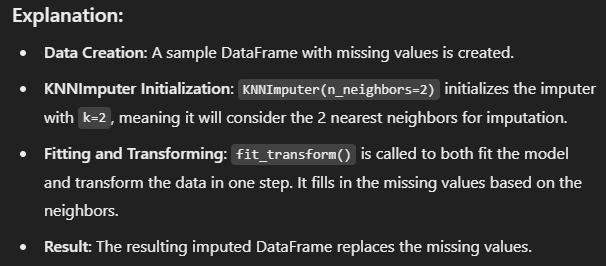

In [8]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [25]:
# (2.1.2) Data Accuracy
# implement rules to flag anomalies
df.describe()

# e.g. if income is < 10,000 and years_employed > 5 - kind of odd that a person still makes under 10,000 after 5 years of employment  
flagged_df = df[ (df['income'] < 1e4) & (df['years_employed'] > 5) ].copy(deep=True)
flagged_df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
2595,3889766,2,46.783973,112.606971,1000.000000,10,674,0
2775,6379071,2,260.082886,534.975766,4771.801670,9,659,0
3651,2571499,3,454.338123,1542.679364,8253.372706,6,625,0
4509,7237328,1,50.203718,103.133734,1000.000000,6,615,0
6795,7208811,1,80.689935,78.613971,1053.763493,6,587,0


In [26]:
# (2.1.3) Data Consistency
# checks for inconsistent data types for each feature
df.map(type).nunique() # returns number of unique values for each column/feature
                       # you want it to return 1 across each column to verify consistency

customer_id                 1
credit_lines_outstanding    1
loan_amt_outstanding        1
total_debt_outstanding      1
income                      1
years_employed              1
fico_score                  1
default                     1
dtype: int64

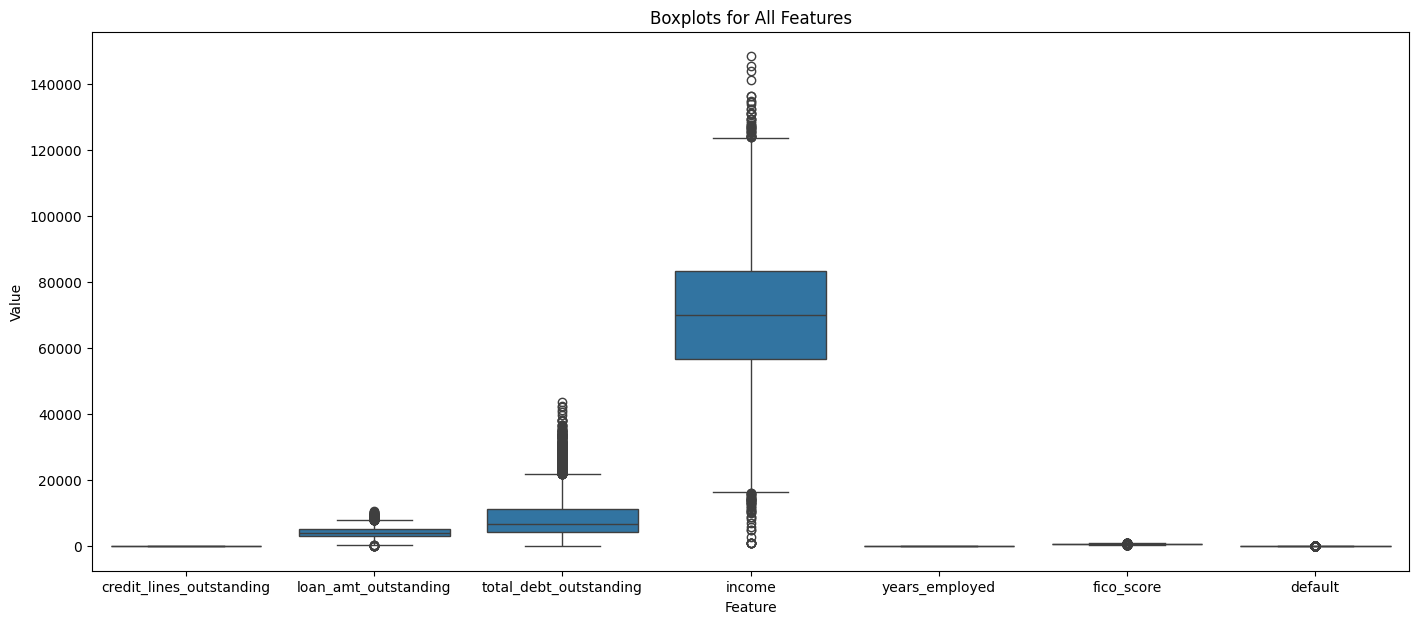

In [27]:
# (2.1.5) Data Outliers

# Reshape the DataFrame to long-form using `pd.melt`
df_melted = pd.melt(df[[x for x in df.columns if x!='customer_id']], var_name='Feature', value_name='Value')

# Create the boxplot
plt.figure(figsize=(17,7))
sns.boxplot(x='Feature', y='Value', data=df_melted)
plt.title('Boxplots for All Features')
plt.show()

# NOTES: in Sudjianto et. al. paper, there other advanced techniques for outlier detection

<Axes: ylabel='Features'>

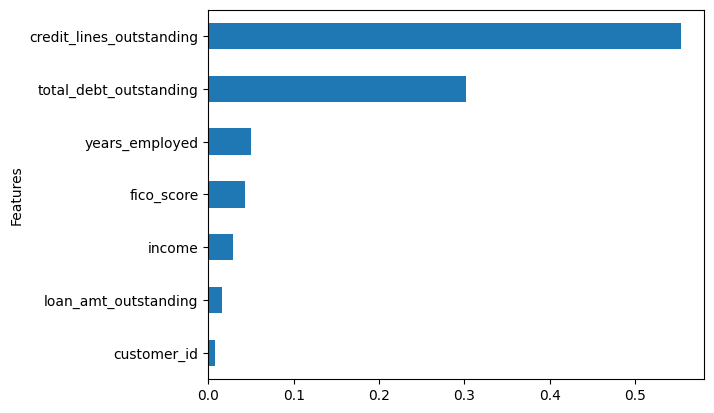

In [ ]:
#(2.1.4) Data Relevance
# IDEA: computing feature importance scores using various methods to give us an idea what features to look at more closely during Feature Selection 

# perform feature importance analysis by deploying a RandomForestClassifier model

from sklearn.ensemble import RandomForestClassifier

# train the Random Forest Classifier model
# best practices ranges:
# SIZE OF DATASETS #####################
# Small: Fewer than 10,000 rows and <50 features.
# Medium: Between 10,000 and 1 million rows.
# Large: More than 1 million rows or hundreds/thousands of features.
# max_depth #############################
# For small or simple datasets, smaller depths (e.g., 3–5) are usually sufficient.
# For large or complex datasets, deeper trees (e.g., 10–20) may be necessary
# n_estimators ##########################
# For small to medium datasets, values between 100 and 500
# For larger datasets or when computational resources are not a concern, values between 500 and 1000

# define the input and target datasets
X_input = df.loc[:,[x for x in df.columns if x!='default']]
y_target = df.loc[:, 'default']
# define the RFC model
rf = RandomForestClassifier(random_state=0, max_features='log2', max_depth=10, n_estimators=100)
# fit the RFC model
rf.fit(X_input, y_target)
# Extract feature importances
importances = rf.feature_importances_
# Visualize feture importances
import matplotlib.pyplot as plt

feat_importance_df = pd.DataFrame(data=[
                                        [x for x in df.columns if x!='def ault'],
                                        importances],
                                 )

feat_importance_df = feat_importance_df.T
feat_importance_df.columns = ['Features', 'Feature Importances']
feat_importance_df = feat_importance_df.set_index('Features')
feat_importance_df.sort_values('Feature Importances').plot(kind='barh', legend=False)

# NOTE: credit lines and total debt outstanding has the highest RFC Feature Importance scores
# take note of causality: if you have more credit lines open, the more probable that you will incur more debt

# feauture_importance is based on the RandomForest model's impurity-importance (e.g. Gini Impurity) during tree construction


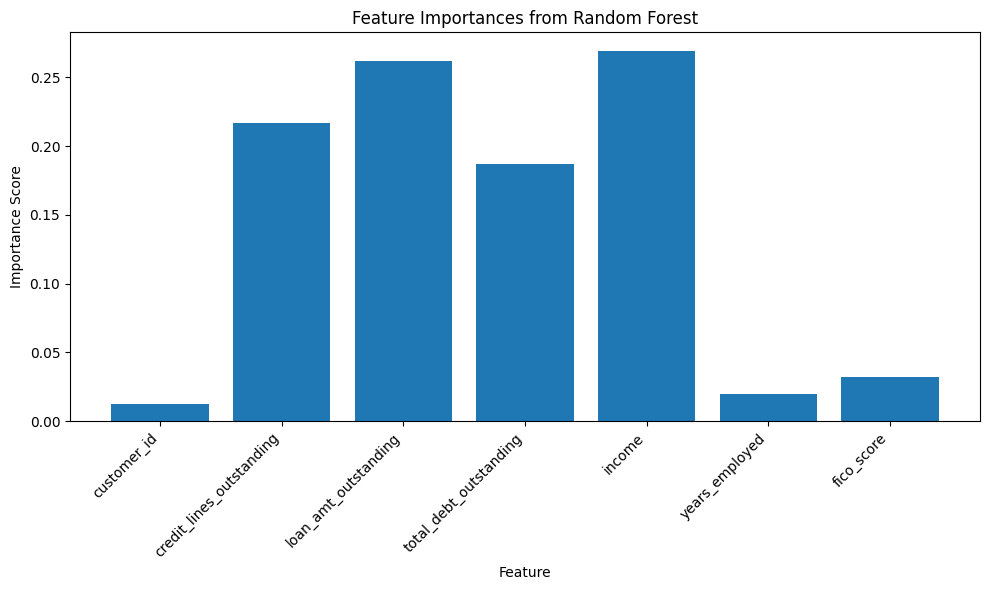


Selected Features: ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income']

Feature Importance Scores:
customer_id: 0.012234589471568347
credit_lines_outstanding: 0.2171346281948107
loan_amt_outstanding: 0.2620191646721182
total_debt_outstanding: 0.18727799496029218
income: 0.2692939499234989
years_employed: 0.019855343311760955
fico_score: 0.03218432946595083

Reduced Dataset Shape: (10000, 4)


In [31]:
# EXTENDED:  K-Means clustering (unsupervised) with Random Forest (supervised) to calculate a weighted importance score.
# this method complements RandomForest's feature_importance computations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def kmeans_random_forest_feature_selection(X, feature_labels, n_clusters=3, n_features_to_select=None):
    """
    Perform feature selection using K-Means and Random Forest with feature labels.
    
    Parameters:
    -----------
    X : numpy array or pandas DataFrame
        Input feature matrix.
    feature_labels : list
        List of feature names corresponding to columns in X.
    n_clusters : int, optional (default=3)
        Number of clusters for K-Means.
    n_features_to_select : int, optional (default=None)
        Number of top features to select. If None, selects features above mean importance.
    
    Returns:
    --------
    selected_features : list
        Names of selected features.
    feature_importances : dict
        Dictionary of feature names and their importance scores.
    """
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Prepare data for Random Forest
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, cluster_labels, test_size=0.3, random_state=42)
    
    # Train Random Forest Classifier
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_classifier.fit(X_train, y_train)
    
    # Get feature importances
    feature_importances = rf_classifier.feature_importances_
    
    # Create a dictionary of feature names and their importance scores
    importance_dict = {feature: importance for feature, importance in zip(feature_labels, feature_importances)}
    
    # Select features
    if n_features_to_select is None:
        # Select features above mean importance
        mean_importance = np.mean(feature_importances)
        selected_features = [feature for feature, importance in importance_dict.items() if importance > mean_importance]
    else:
        # Select top n features based on importance scores
        sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
        selected_features = [feature for feature, _ in sorted_features[:n_features_to_select]]
    
    # Visualize feature importances
    plt.figure(figsize=(10, 6))
    plt.bar(feature_labels, feature_importances)
    plt.title('Feature Importances from Random Forest')
    plt.xlabel('Feature')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return selected_features, importance_dict

# input data
X = df.loc[:, [x for x in df.columns if x !='default']]
y = df['default']

# Convert to DataFrame for easier handling and assign column names
feature_names = [feat for feat in X.columns]
X_df = pd.DataFrame(X, columns=feature_names)

# Perform feature selection with K-Means and Random Forest
selected_features, importances = kmeans_random_forest_feature_selection(X_df.values, feature_names, n_clusters=3)

# Print results
print("\nSelected Features:", selected_features)
print("\nFeature Importance Scores:")
for feature_name, score in importances.items():
    print(f"{feature_name}: {score}")

# Demonstrate feature selection by creating a reduced dataset with selected features
X_reduced = X_df[selected_features]
print("\nReduced Dataset Shape:", X_reduced.shape)


<Figure size 1200x1000 with 0 Axes>

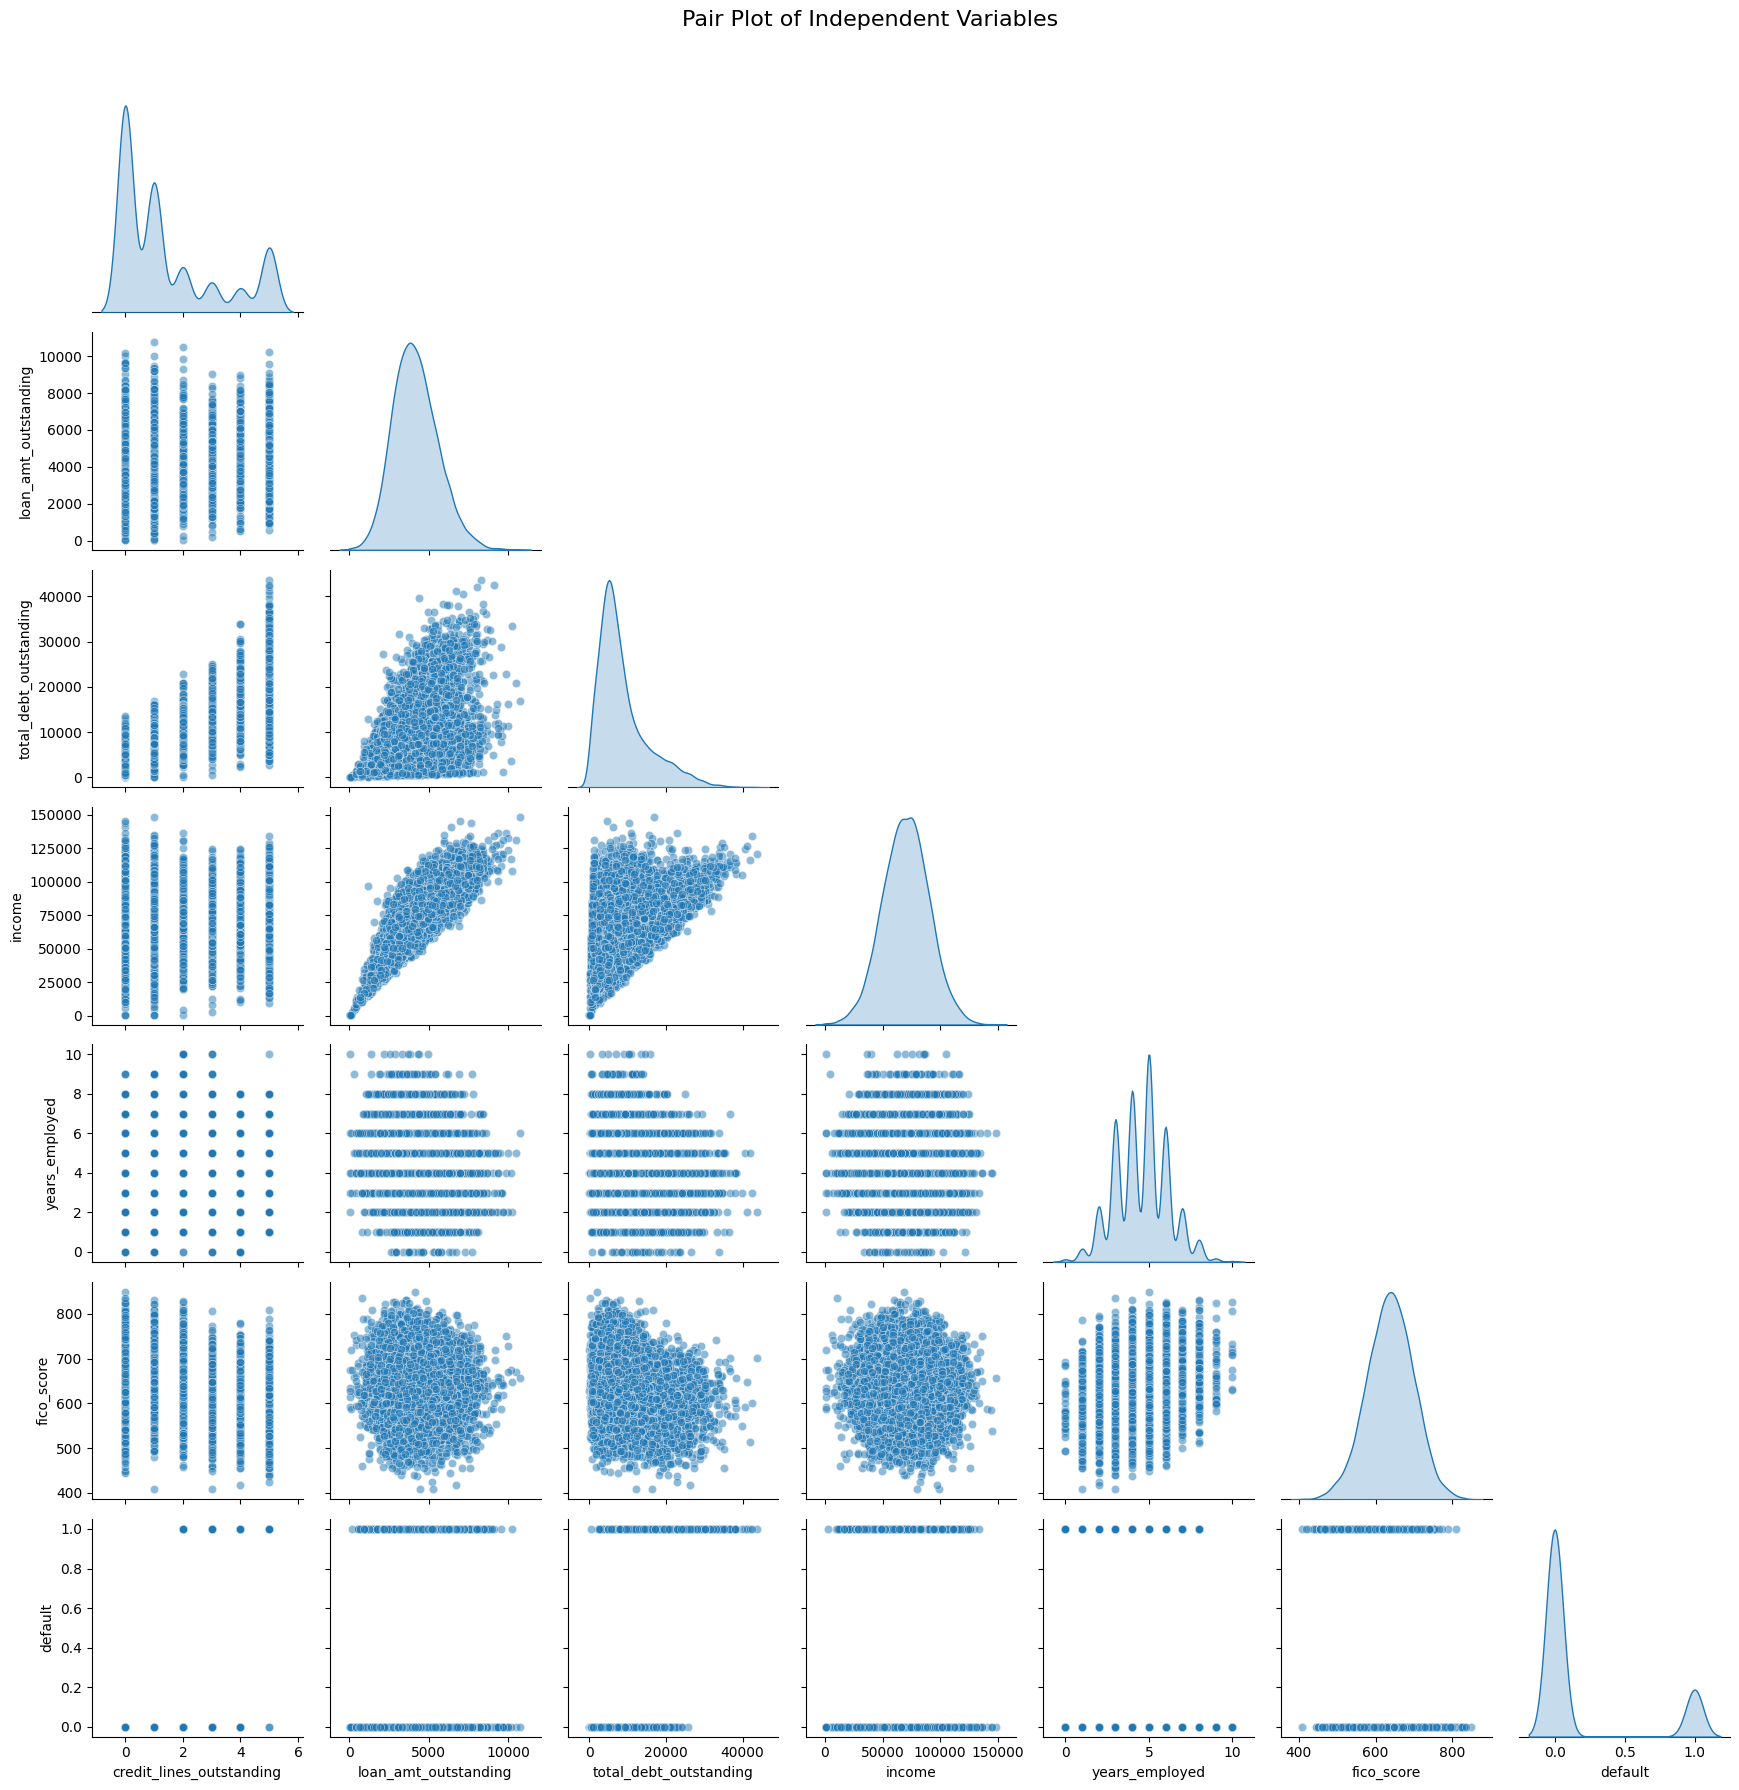

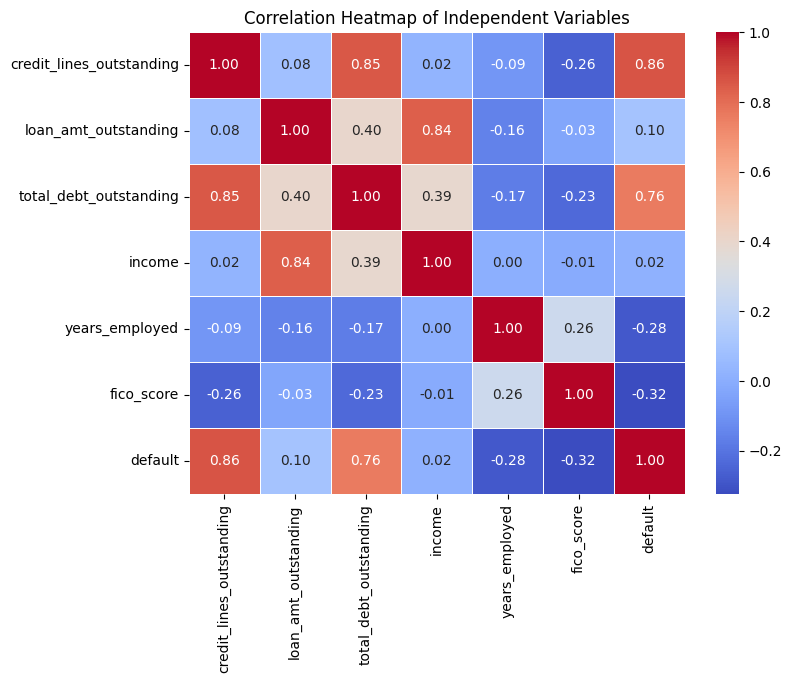

In [34]:
# (2.2.1) and (2.2.2) Feature Selection (and Feature Engineering if applicable)
# IDEA: we look out for relationships among independent variables and independent to depenedent variables

# Determine LINEAR Relationship among the independent variables in the dataset

# NOTE: modify viz_df in the above cells accordingly
viz_df = df.loc[:,[x for x in df.columns if x not in ['customer_id']]] # df.loc[:, selected_features]#  # choose the features to plot

plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(viz_df, diag_kind='kde', plot_kws={'alpha': 0.5}, corner=True)
pair_plot.fig.suptitle('Pair Plot of Independent Variables', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Correlation Heatmap to Quantify Multicollinearity
correlation_matrix = viz_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Independent Variables")
plt.show()


# REMARK: ask the professor on how to proceed with feature selection/engineering given the plots below


Pairwise Mutual Information Scores:
                         credit_lines_outstanding loan_amt_outstanding  \
credit_lines_outstanding                        0             1.512236   
loan_amt_outstanding                     1.512236                    0   
total_debt_outstanding                   1.512236              9.21034   
income                                   1.511629             9.209265   
years_employed                           0.137445             1.862592   
fico_score                               0.140781             5.500121   
default                                  0.420882             0.479039   

                         total_debt_outstanding    income years_employed  \
credit_lines_outstanding               1.512236  1.511629       0.137445   
loan_amt_outstanding                    9.21034  9.209265       1.862592   
total_debt_outstanding                        0  9.209265       1.862592   
income                                 9.209265         0       1.8

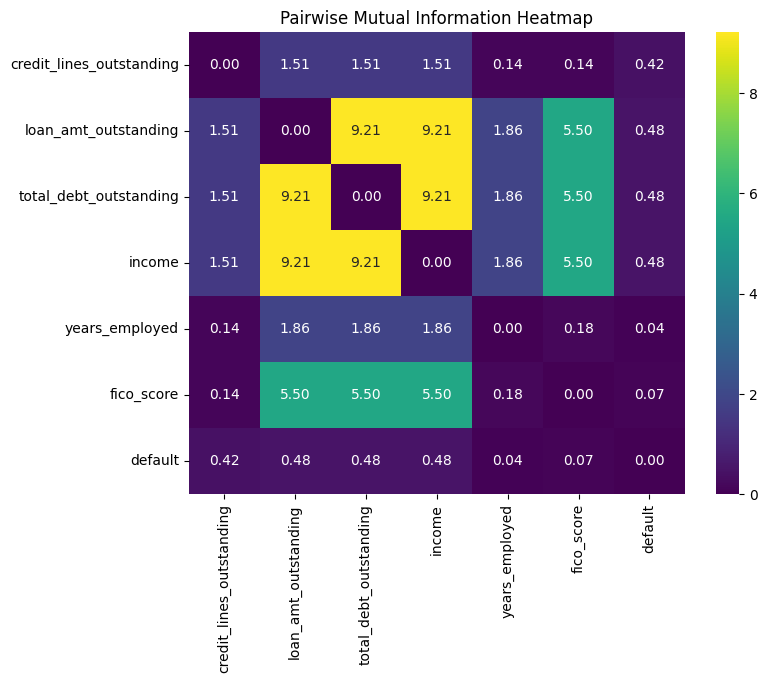

In [15]:
# Deploy Multivariate Mutual Information Scoring among each possible variable pair to determine independence/dependence in a probabilistic sense


import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

def pairwise_mutual_information(X):
    """
    Calculate pairwise mutual information scores for all feature pairs.
    
    Parameters:
    - X: Feature matrix (DataFrame or ndarray)
    
    Returns:
    - A DataFrame containing mutual information scores for each feature pair.
    """
    # Ensure X is a DataFrame for easier indexing
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
    
    # Initialize an empty DataFrame to store MI scores
    mi_matrix = pd.DataFrame(index=X.columns, columns=X.columns)
    
    # Calculate mutual information for each pair of features
    for i in range(len(X.columns)):
        for j in range(i, len(X.columns)):  # Only compute upper triangular (symmetric matrix)
            if i == j:
                mi_matrix.iloc[i, j] = 0  # MI with itself is zero
            else:
                mi_score = mutual_info_score(X.iloc[:, i], X.iloc[:, j])
                mi_matrix.iloc[i, j] = mi_score
                mi_matrix.iloc[j, i] = mi_score  # Symmetric value
    
    return mi_matrix

# Example usage with a synthetic dataset
from sklearn.datasets import make_classification

# Compute pairwise mutual information scores
# NOTE: modify viz_df in the above cells accordingly
pairwise_mi_scores = pairwise_mutual_information(viz_df)

# Display the results
print("Pairwise Mutual Information Scores:")
print(pairwise_mi_scores)

# Optional: Visualize the pairwise MI matrix as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(pairwise_mi_scores.astype(float), annot=True, cmap="viridis", fmt=".2f")
plt.title("Pairwise Mutual Information Heatmap")
plt.show()


# REMARKS:
# low score ~0 = variables are independent from each other - desired among independent variables
# high score = variables are dependent from each other - desired between independent and dependent variables

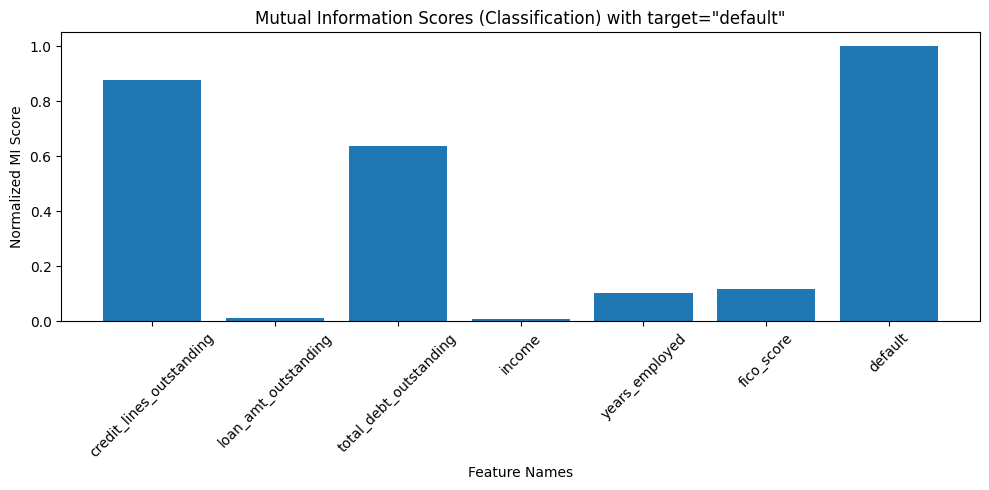

Classification MI Scores:
credit_lines_outstanding: 0.8759623848464668
loan_amt_outstanding: 0.010553598009259358
total_debt_outstanding: 0.635038348793304
income: 0.007972580668592025
years_employed: 0.10361609626900975
fico_score: 0.11731084585183929
default: 1.0


In [16]:
# Univariate Mutual Information of independent variables to the dependent variable

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# Function to calculate and visualize mutual information
def calculate_mutual_information(X, y, task='regression'):
    """
    Calculate mutual information between features and target variable.
    
    Parameters:
    - X: Feature matrix
    - y: Target variable
    - task: 'regression' or 'classification'
    
    Returns:
    - Mutual information scores for each feature
    """
    # Select appropriate mutual information function based on task
    if task == 'regression':
        mi_func = mutual_info_regression
    elif task == 'classification':
        mi_func = mutual_info_classif
    else:
        raise ValueError("Task must be 'regression' or 'classification'")
    
    # Calculate mutual information scores
    mi_scores = mi_func(X, y)
    
    # Normalize scores to [0, 1] for better interpretability
    mi_scores = mi_scores / np.max(mi_scores)
    
    return mi_scores


# NOTE: modify viz_df in the above cells accordingly
# change task accordingly
mi_scores_clf = calculate_mutual_information(viz_df, viz_df['default'], task='classification')

# Extract feature names (excluding the target column)
feature_labels = viz_df.columns

'''
# Visualization for regression
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(len(mi_scores_reg)), mi_scores_reg)
plt.title('Mutual Information Scores (Regression)')
plt.xlabel('Feature Index')
plt.ylabel('Normalized MI Score')
'''



# Visualization for classification with relabeled x-axis
plt.figure(figsize=(10, 5))
plt.bar(range(len(mi_scores_clf)), mi_scores_clf, tick_label=feature_labels)
plt.title('Mutual Information Scores (Classification) with target="default"')
plt.xlabel('Feature Names')
plt.ylabel('Normalized MI Score')
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.tight_layout()
plt.show()

# Print classification MI scores with feature names
print("Classification MI Scores:")
for feature, score in zip(feature_labels, mi_scores_clf):
    print(f"{feature}: {score}")


# REMARK: same result as feature importance in RandomForest
# high score means that the independent variable has high probabilistic dependency with the dependent variable
# low score means that the independent variable has probabilistic independence with the dependent variable



In [17]:
# based from the above analysis, will use the following features
features = ['total_debt_outstanding','fico_score', 'income']
# inputs to chi-squared test
categorical_feat = ['fico_score'] # list out categorical variables 
continuous_feat = [x for x in features if x not in categorical_feat]


In [18]:
# (2.3) Model Selection - pre-amble

# Function for evaluating predictive models

def evaluate_model(y_true, y_pred, y_scores):

    import numpy as np
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        log_loss,
        roc_auc_score,
        average_precision_score,
        confusion_matrix,
        roc_curve,
        auc
    )
    import matplotlib.pyplot as plt



    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cross_entropy_loss = log_loss(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    # Print metrics
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"cross_entropy_loss: {cross_entropy_loss:.2f}")
    print(f"ROC-AUC: {roc_auc:.2f}")
    print(f"PR-AUC: {pr_auc:.2f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Optional: Plot Precision-Recall Curve
    from sklearn.metrics import precision_recall_curve

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_scores)
    plt.figure()
    plt.plot(recall_vals, precision_vals,
            label=f'PR curve (AUC = {pr_auc:.2f})', color='blue')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()


In [19]:
# (2.3) Model Selection

'''
# MODEL 1: Logistic Regression
# as per industry standards, Logistic Regression is widely used for predicting Probability of Default
# theory: https://www.youtube.com/watch?v=zM4VZR0px8E


Assumptions of Logistic Regression

Binary or Ordinal Dependent Variable:
For binary logistic regression, the dependent variable must have two categories (e.g., yes/no, 0/1). For ordinal logistic regression, the dependent variable should have ordered categories135.

Independence of Observations:
The observations in the dataset must be independent of each other. This means there should be no repeated measurements or matched data unless accounted for in the model235.
 - use chi-squared test

No Perfect Multicollinearity:
The independent variables should not be perfectly correlated with each other. High multicollinearity can distort coefficient estimates and reduce interpretability357.


Linearity of Independent Variables and Log-Odds:
Logistic regression assumes that continuous independent variables have a linear relationship with the log-odds (logit) of the dependent variable. This can be checked using methods like the Box-Tidwell test or scatterplots with log-odds transformations235.
- Box-Tidwell test

Adequate Sample Size:
Logistic regression requires a sufficiently large sample size to ensure reliable estimates. A general rule is to have at least 10 cases with the least frequent outcome for each independent variable in the model35.

Absence of Strongly Influential Outliers:
Outliers can significantly impact the results of logistic regression. It is important to identify and address such data points during analysis7.

'''

# BOX-TIDWELL TEST function definition

import numpy as np
import pandas as pd
import statsmodels.api as sm
import warnings

# Suppress warnings to keep output clean
warnings.filterwarnings('ignore')

def box_tidwell_test(X, y, alpha=0.05):
    """
    Perform the Box-Tidwell test to check the linearity assumption of continuous predictors 
    in logistic regression.
    
    Parameters:
    -----------
    X : pandas DataFrame
        Continuous predictors (each column is a predictor).
    y : pandas Series or numpy array
        Binary outcome variable (0 or 1).
    alpha : float, optional (default=0.05)
        Significance level for hypothesis testing.
    
    Returns:
    --------
    results : dict
        Dictionary containing p-values and linearity assumption results for each predictor.
    """
    
    # Ensure all predictors are positive by adding a small constant if necessary
    X_adjusted = X + 1  # Add 1 to avoid log(0)
    
    # Create interaction terms: X * log(X)
    interaction_terms = X_adjusted * np.log(X_adjusted)
    
    # Rename interaction term columns
    interaction_terms.columns = [f"{col}_interaction" for col in X.columns]
    
    # Combine original predictors and interaction terms into one DataFrame
    predictors = pd.concat([X_adjusted, interaction_terms], axis=1)
    
    # Add a constant for the intercept in logistic regression
    predictors = sm.add_constant(predictors)
    
    # Fit logistic regression model with both original predictors and interaction terms
    model = sm.Logit(y, predictors).fit(disp=False)
    
    # Extract p-values for the interaction terms (after original predictors)
    num_predictors = X.shape[1]
    p_values = model.pvalues[num_predictors + 1:]  # Skip intercept and original predictors
    
    # Determine linearity assumption based on p-values
    results = {}
    for i, predictor in enumerate(X.columns):
        p_value = p_values[i]
        results[predictor] = {
            "p_value": p_value,
            "linearity_holds": p_value > alpha,  # True if linearity assumption holds
            "coefficient": model.params[num_predictors + 1 + i]  # Interaction term coefficient
        }
    
    return results




# CHI-SQUARED TEST with discretization step for continuous independent variables

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.preprocessing import KBinsDiscretizer

def chi_squared_mixed_dataset(df, categorical_cols=None, continuous_cols=None, n_bins=5, alpha=0.05):
    """
    Perform chi-squared test on all possible variable pairs in a mixed dataset and indicate independence.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataset with mixed variable types.
    categorical_cols : list, optional
        List of categorical column names.
    continuous_cols : list, optional
        List of continuous column names.
    n_bins : int, default 5
        Number of bins for discretizing continuous variables.
    alpha : float, default 0.05
        Significance level for determining independence.
    
    Returns:
    --------
    results : dict
        Dictionary containing chi-squared statistics, p-values, and independence indicators as DataFrames.
    """
    # Infer column types if not provided
    if categorical_cols is None and continuous_cols is None:
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
        continuous_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    # Discretize continuous variables
    if continuous_cols:
        discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        df.loc[:,continuous_cols] = discretizer.fit_transform(df[continuous_cols])
    
    # Combine all columns for pairwise analysis
    all_cols = categorical_cols + continuous_cols
    
    # Initialize matrices for results
    n_cols = len(all_cols)
    chi2_matrix = np.zeros((n_cols, n_cols))
    pvalue_matrix = np.zeros((n_cols, n_cols))
    independence_matrix = np.full((n_cols, n_cols), True)  # Default to True (independent)
    
    # Compute chi-squared tests for all pairs
    for i in range(n_cols):
        for j in range(i, n_cols):
            contingency_table = pd.crosstab(df[all_cols[i]], df[all_cols[j]])
            chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
            chi2_matrix[i, j] = chi2_stat
            chi2_matrix[j, i] = chi2_stat
            pvalue_matrix[i, j] = p_value
            pvalue_matrix[j, i] = p_value
            
            # Determine independence based on the p-value and significance level (alpha)
            is_independent = p_value > alpha
            independence_matrix[i, j] = is_independent
            independence_matrix[j, i] = is_independent
    
    # Convert matrices to DataFrames
    chi2_df = pd.DataFrame(chi2_matrix, index=all_cols, columns=all_cols)
    pvalue_df = pd.DataFrame(pvalue_matrix, index=all_cols, columns=all_cols)
    independence_df = pd.DataFrame(independence_matrix, index=all_cols, columns=all_cols)
    
    return {
        'chi2_statistics': chi2_df,
        'p_values': pvalue_df,
        'independence': independence_df
    }

######################## APPLYING THE TESTS ###############################

# Before deploying a LogisticRegression model, we need to check if our dataset satisfies the assumptions of this model

input_df = df.copy(deep=True)
# CHI-SQUARED TEST: test for [probabilistic] independence among independent variables
print('========= CHI-SQUARED TEST =========\n')
results = chi_squared_mixed_dataset(
    df[features],
    categorical_cols= categorical_feat, #["credit_lines_outstanding", "years_employed", "fico_score"],
    continuous_cols= continuous_feat, #["loan_amt_outstanding", "total_debt_outstanding", 'income'],
    alpha=0.05  # Significance level for independence test
)

print("Chi-squared Statistics:")
print(results['chi2_statistics'])
print("\nP-values:")
print(results['p_values'])
print("\nIndependence (True indicates independent):")
print(results['independence'])



# BOX-TIDWELL TEST: test for linear relationship of independent variables with the logit of the dependent variable
print('\n========= BOX-TIDWELL TEST =========\n')
# Input Data
X = df[features] # df.loc[:, [x for x in df.columns if x!='default']]
y = df['default']

# Perform Box-Tidwell Test on synthetic data
results = box_tidwell_test(X, y)

# Display results
print("Box-Tidwell Test Results:")
print("-" * 50)
for predictor, result in results.items():
    print(f"{predictor}:")
    print(f"  P-value: {result['p_value']:.4f}")
    print(f"  Coefficient: {result['coefficient']:.4f}")
    print(f"  Linearity Assumption: {'Holds' if result['linearity_holds'] else 'Violated'}")




# CHI-SQUARED TEST with discretization step for continuous independent variables
# Null Hypothesis: The two variables are independent
# Alternative Hypothesis: The two variables are not independent
# NOTE: you want independent variables to FAIL TO REJECT the H0 (i.e. independent variables are probabilistically independent) to satisfy assumption for Logistic Regression

# BOX-TIDWELL TEST function definition
# Null Hypothesis: The coefficient for the interaction term is not significant, which implies that the relationship between the predictor (independent) variable and the logit is linear
# Alternative Hypothesis: The coefficient for the interaction term is significant, which implies that the relationship between the predictor variable and the logit is non-linear
# NOTE: you want the the test to result to FAIL TO REJECT the H0 meaning that the log transformations of the independent variables are linear and meets the assumption of the Logistic Regression



========= CHI-SQUARED TEST =========

Chi-squared Statistics:
                          fico_score  total_debt_outstanding        income
fico_score              3.730000e+06             2202.288864   1487.238142
total_debt_outstanding  2.202289e+03            40000.000000   1781.315000
income                  1.487238e+03             1781.315000  40000.000000

P-values:
                          fico_score  total_debt_outstanding    income
fico_score              0.000000e+00            2.503281e-30  0.529915
total_debt_outstanding  2.503281e-30            0.000000e+00  0.000000
income                  5.299153e-01            0.000000e+00  0.000000

Independence (True indicates independent):
                        fico_score  total_debt_outstanding  income
fico_score                   False                   False    True
total_debt_outstanding       False                   False   False
income                        True                   False   False

========= BOX-TIDWELL TEST ===

Coefficients: [[ 0.00195149 -0.0222075  -0.0004002 ]]
Intercept: [13.68344299]
Accuracy: 0.98
Precision: 0.96
Recall: 0.94
F1 Score: 0.95
cross_entropy_loss: 0.66
ROC-AUC: 1.00
PR-AUC: 0.99

Confusion Matrix:
[[2020   19]
 [  27  434]]


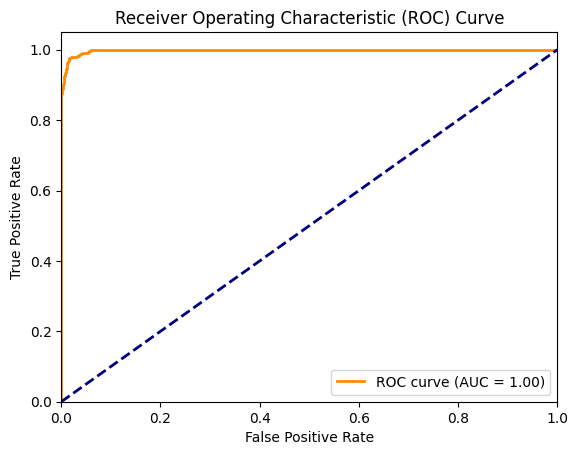

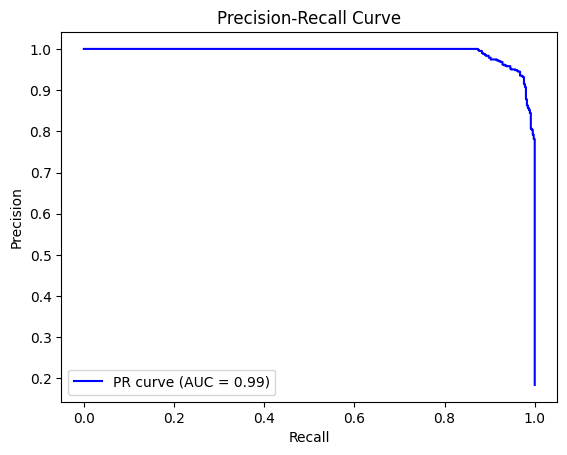

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load your dataset (replace with your own data)
# X: Features, y: Target variable (binary)

# features = ['total_debt_outstanding', 'fico_score']

'''
Normalizing Dataset if required

# Normalizing independent variables since it is best practice for logistic regression
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the dataset
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(data=df_scaled, columns=df.columns)
'''

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df['default'], random_state=7)

# Initialize the logistic regression model
model = LogisticRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# show the regression coefficients and intercept:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# process inputs and outputs for evaluation
y_true = y_test
y_scores = model.predict_proba(X_test)[:,1]

evaluate_model(y_true, y_pred, y_scores)

# REMARK: cross_entropy_loss is interpreted as the distance between two probability distributions (i.e. true and predicted)
#         lower values are desirable



Precision-Recall

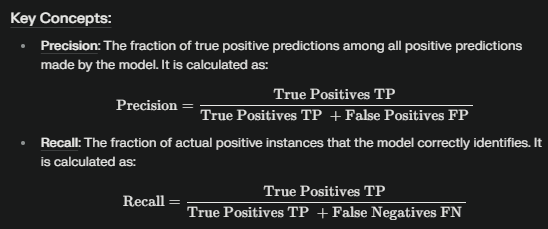


ROC


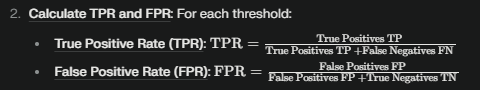

In [39]:
# (2.5) Hyperparmeter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {'C': [0.0001, 0.001, 0.01, 0.1, 1, 100], 
              'penalty': ['elasticnet'], 
              'l1_ratio': np.arange(start=0, stop=1, step=0.1),
              'solver': ['saga'] # only set to saga in order to use elasticnet
              }
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(df[features], df['default'])
print("Best Parameters:", grid_search.best_params_)



Best Parameters: {'C': 0.01, 'l1_ratio': 0.30000000000000004, 'penalty': 'elasticnet', 'solver': 'saga'}


Coefficients: [[ 0.00149592 -0.00010704 -0.0003091 ]]
Intercept: [-6.72887093e-08]
Accuracy: 0.98
Precision: 0.96
Recall: 0.94
F1 Score: 0.95
cross_entropy_loss: 0.65
ROC-AUC: 1.00
PR-AUC: 0.99

Confusion Matrix:
[[2021   18]
 [  27  434]]


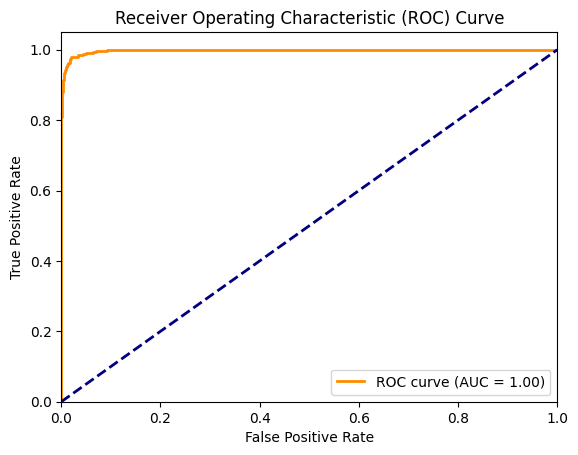

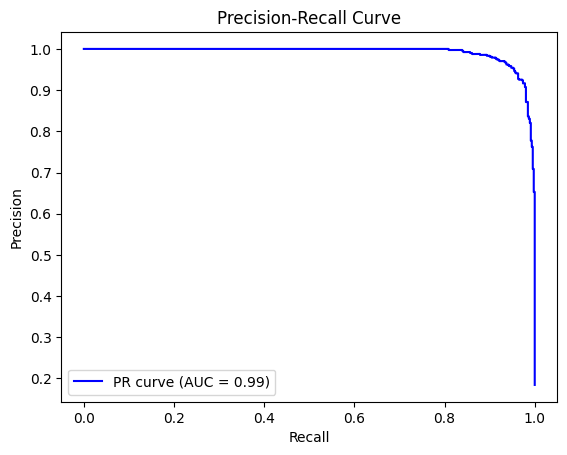

In [42]:
# apply the best parameters and re-evaluate

# Initialize the logistic regression model
model = LogisticRegression(C=grid_search.best_params_['C'], 
                           l1_ratio=grid_search.best_params_['l1_ratio'], 
                           penalty=grid_search.best_params_['penalty'], 
                           solver=grid_search.best_params_['solver'])

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# show the regression coefficients and intercept:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# process inputs and outputs for evaluation
y_true = y_test
y_scores = model.predict_proba(X_test)[:,1]

evaluate_model(y_true, y_pred, y_scores)

In [ ]:
# GIVEN THE ABOVE LOGISTIC REG MODEL, FIGURE OUT HOW TO CALCULATE PD AND EXPECTED LOSS
# theory: https://www.wallstreetmojo.com/probability-of-default/

# Probability of Default - likelihood that borrower will default 
# Recovery Rate (RR) - % of borrowed capital that can be recovered
# Loss Given Default (LGD) - % of borrowed capital that is lost or cannot be recovered, i.e. LGD = 1 - RR
# Exposure at Default (EAD) - $ amount at which the lender will lose when the borrower default; a.k.a. "borrowed capital"

#  assumptions: RR = 10%
# find: (1) probability density function of PD , 
#       (2) Expected Loss = PD * EAD * LGD
#             source:  https://fastercapital.com/topics/expected-loss-(el).html#:~:text=from%20various%20perspectives.-,1.,loss%20given%20default%20(LGD).

# (1) PD(z) = 1 / (1 + e^(-z)), where z = β0 + β1*×1 + β2*×2 + … + βn*xn
#                               where β1, β2, …, βn are the coefficients associated with each borrower characteristic.
#                               where x1, x2, …, xn are the values of the borrower’s characteristics.
#           how to extract β and x from the logistic regression model? - model.coef_ for βn
#                                                                      - model.intercept_ for β0 intercept
# how β is calculated?? - stochastic gradient descent! theory: https://machinelearningmastery.com/logistic-regression-tutorial-for-machine-learning/

# (2) given RR = 10%, Loss Given Default (LGD) = 90%, 

# (3) EAD = loan_amount_outstanding

In [43]:
# construct function that vectorially computes probability density of PoD using parameters obtained from Logistic Regression and features dataset
def PoD_density_compute(intercept, coeff_list, df_features):
    # compute z = β0 + β1*×1 + β2*×2 + … + βn*xn
    z_df = intercept + df_features.multiply(coeff_list, axis='columns').sum(axis=1)
    # define the sigmoid function as the probability density function: PD(z) = 1 / (1 + e^(-z))
    sigmoid = lambda z: 1/(1+np.exp(-z))

    return pd.DataFrame(data=sigmoid(z_df), columns=['PoD']) # vectorially computes the probability density function

PoD_df = PoD_density_compute(model.intercept_, model.coef_, X_test) # PoD in df form

EAD_df = df.loc[X_test.index,['loan_amt_outstanding']] # EAD to be loan amount outstanding

# assume RR = 10% which follows Loss Given Default (LGD) = 90%, 
RR = 0.10; LGD = 1 - RR;

# compute Expected Loss vectorially: PD * EAD * LGD
EL_ser = PoD_df['PoD'] * EAD_df['loan_amt_outstanding'] * LGD
EL_df = pd.DataFrame(data=EL_ser, columns=['EL'])

# consolidate results
concat_df = pd.concat([X_test,y_test,PoD_df,EL_df],axis=1)
concat_df

,total_debt_outstanding,fico_score,income,default,PoD,EL
1977,8038.248905,697,78495.47252,0,4.492869e-06,1.293004e-02
3880,18391.211750,567,101294.48810,0,2.065258e-02,1.144823e+02
52,4179.967159,610,36004.06641,0,7.094836e-03,1.205589e+01
2551,4709.254935,516,70372.95945,0,3.877565e-07,1.124899e-03
2246,2329.688758,743,90594.85581,0,2.077142e-11,6.101370e-08
...,...,...,...,...,...,...
1355,5796.005855,679,59806.79967,0,5.074594e-05,1.458800e-01
4856,6713.580429,713,77522.10861,0,8.353089e-07,2.232195e-03
2392,14473.137850,566,79350.00501,0,5.035349e-02,2.204741e+02
3734,2860.209762,772,52883.03423,0,5.287447e-06,1.665945e-02


In [44]:
concat_df[ concat_df['default'] == 0 ]

,total_debt_outstanding,fico_score,income,default,PoD,EL
1977,8038.248905,697,78495.47252,0,4.492869e-06,1.293004e-02
3880,18391.211750,567,101294.48810,0,2.065258e-02,1.144823e+02
52,4179.967159,610,36004.06641,0,7.094836e-03,1.205589e+01
2551,4709.254935,516,70372.95945,0,3.877565e-07,1.124899e-03
2246,2329.688758,743,90594.85581,0,2.077142e-11,6.101370e-08
...,...,...,...,...,...,...
1355,5796.005855,679,59806.79967,0,5.074594e-05,1.458800e-01
4856,6713.580429,713,77522.10861,0,8.353089e-07,2.232195e-03
2392,14473.137850,566,79350.00501,0,5.035349e-02,2.204741e+02
3734,2860.209762,772,52883.03423,0,5.287447e-06,1.665945e-02


Ending Remarks:

For further analysis, continue Sudjianto's Model Validation framework by going through Outcome Analsysis and On-going Monitoring steps

In Outcome Analysis, the weaknesses of the model that was developed here can be identified and addressed to further improve the model to be production-grade

Trying out other models

Accuracy: 0.98
Precision: 0.96
Recall: 0.93
F1 Score: 0.94
cross_entropy_loss: 0.76
ROC-AUC: 1.00
PR-AUC: 0.99

Confusion Matrix:
[[2019   20]
 [  33  428]]


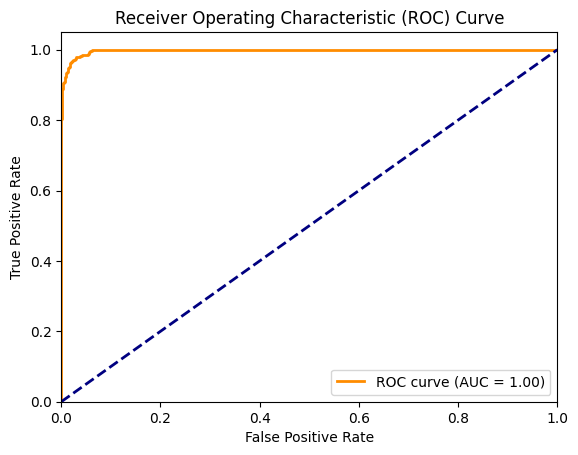

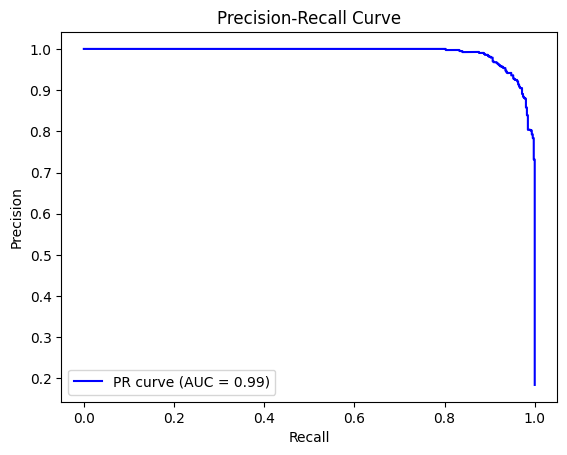

In [52]:
# MODEL 2: RandomForestClassifier

# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load the dataset
iris = load_iris()  # Using the Iris dataset as an example
X = iris.data  # Features (sepal and petal measurements)
y = iris.target  # Target (species of iris)

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df['default'], random_state=7)

# Step 3: Create and configure the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=0, max_features='log2', max_depth=10, n_estimators=100)

# Step 4: Train the model on the training set
rf_model.fit(X_train, y_train)

# Step 5: Make predictions on the test set
y_pred = rf_model.predict(X_test)

# process inputs and outputs for evaluation
y_true = y_test
y_scores = rf_model.predict_proba(X_test)[:,1]

# evaluate the model
evaluate_model(y_true, y_pred, y_scores)



Accuracy: 0.98
Precision: 0.95
Recall: 0.95
F1 Score: 0.95
cross_entropy_loss: 0.69
ROC-AUC: 1.00
PR-AUC: 0.99

Confusion Matrix:
[[2016   23]
 [  25  436]]


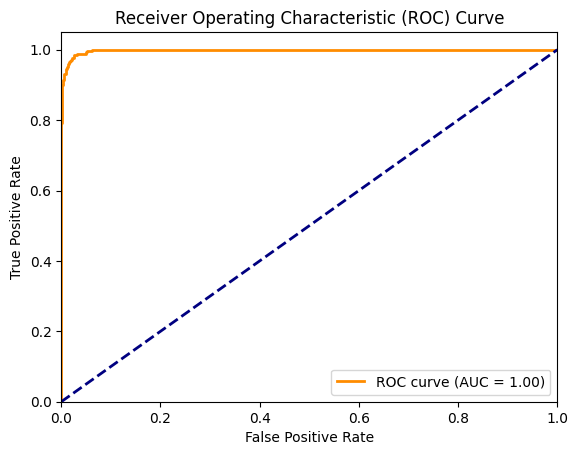

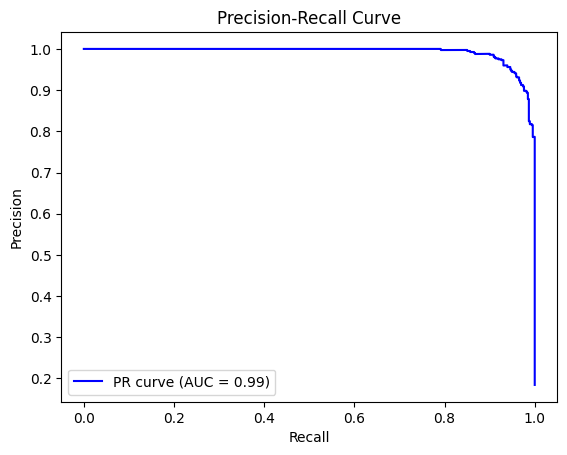

In [53]:
# MODEL 3: XGBoostClassifier

# Import necessary libraries
import xgboost as xgb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df['default'], random_state=7)

# Step 3: Create and configure the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,          # Number of trees (boosting rounds)
    learning_rate=0.1,         # Step size shrinkage for updates
    max_depth=10,               # Maximum depth of a tree
    random_state=7,           # Ensures reproducibility
    use_label_encoder=False,   # Avoid warning for label encoder
    eval_metric='mlogloss'     # Evaluation metric for multi-class classification
)

# Step 4: Train the model on the training set
xgb_model.fit(X_train, y_train)

# Step 5: Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# process inputs and outputs for evaluation
y_true = y_test
y_scores = xgb_model.predict_proba(X_test)[:,1]

# evaluate the model
evaluate_model(y_true, y_pred, y_scores)



In [54]:
# MODEL 4: AutoGluon modeling

# Import necessary libraries
from autogluon.tabular import TabularPredictor
import pandas as pd


# Specify the label column (target variable)
label = 'default'  # Replace with the name of your target column

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df['default'], random_state=7)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Step 3: Train the AutoGluon model
predictor = TabularPredictor(label=label, path='autogluon_models').fit(train_data)

# Step 4: Evaluate the model on the test data
performance = predictor.evaluate(test_data)

# Step 5: Make predictions on new data (optional)
predictions = predictor.predict(test_data.drop(columns=[label]))

# Print results
print("Model Performance:", performance)
print("Predictions:\n", predictions.head())


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          16
Memory Avail:       2.69 GB / 15.68 GB (17.2%)
Disk Space Avail:   35.09 GB / 475.97 GB (7.4%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions and benchmarks.
	presets='high'         : Strong accuracy with fast inference speed.
	presets='good'         : Good accurac

Model Performance: {'accuracy': 0.98, 'balanced_accuracy': 0.9633970546150499, 'mcc': 0.9331131675149286, 'roc_auc': 0.9982137898825398, 'f1': 0.9452954048140044, 'precision': 0.9536423841059603, 'recall': 0.9370932754880694}
Predictions:
 1977    0
3880    0
52      0
2551    0
2246    0
Name: default, dtype: int64


Outcome Analysis

1. Identifying Model Weaknesses

2. Assessing Reliability of the model outputs

3. Evaluating robustness against input noise to prevent benign overfitting

4. Testing the model's resilience to distribution drift and environmental change

REDO - more extensive data processing
- apply normalization

In [55]:
# we will be approaching this task based on Agus Sudianto's paper on Model Validation 
# using the SR11-7 regulatory guidance in Model Risk Management:
# (2) Conceptual Soundness Evaluation - pre-processing data, feature selection/engineering, model selection, explainability & interpretability, parameter & hyperparameter optimization
# (3) Outcome Analysis - 
# (4) Ongoing Monitoring

import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\jpkdu\Documents\GitHub\FinancialEngineering\JPMorgan - Quant Research\Task 3\Task 3 and 4_Loan_Data.csv")
 
df_play = df.copy(deep=True) # dataset to manipulate with


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [41]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


determine how many unique values do the discrete numerical columns (e.g. credit lines outstanding, years employed)

In [52]:
df[['credit_lines_outstanding', 'years_employed']].nunique()

# will treat as numeric (continuous approx) since the intervals between the values are equal and there are more than 5 values making it ineligible for one-hot encoding

credit_lines_outstanding     6
years_employed              11
dtype: int64

apply normalization using sklearn MinMax
- you can also use standardization to address the outliers in loan amount, total debt, income

In [56]:
# remove customer_id column
df = df.drop(columns='customer_id')

In [64]:
from sklearn.preprocessing import MinMaxScaler

# initialize scaler
scaler = MinMaxScaler()

# fit and transform dataset
# note: it's fine to include the target variable "default" because it's just binary, the transform will not affect it 
scaled_arr = scaler.fit_transform(df)

# revert back to df
normalized_df = pd.DataFrame(data=scaled_arr, columns=df.columns)
normalized_df

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,0.0,0.483447,0.088962,0.522612,0.5,0.445701,0.0
1,1.0,0.178640,0.187761,0.173991,0.2,0.371041,1.0
2,0.0,0.309815,0.045724,0.440036,0.4,0.438914,0.0
3,0.0,0.440948,0.056579,0.497631,0.5,0.461538,0.0
4,0.2,0.121362,0.039791,0.152283,0.6,0.504525,0.0
...,...,...,...,...,...,...,...
9995,0.0,0.279045,0.057770,0.282823,0.5,0.653846,0.0
9996,0.2,0.382987,0.124298,0.535705,0.8,0.468326,0.0
9997,0.4,0.284143,0.109523,0.252304,0.5,0.425339,0.0
9998,0.0,0.302891,0.023168,0.338706,0.2,0.540724,0.0


Feature Importance scoring using RFC
- shown identical result as in un-normalized dataset
- think about the causality: if you have more credit lines open, you may acquire more debt

<Axes: ylabel='Features'>

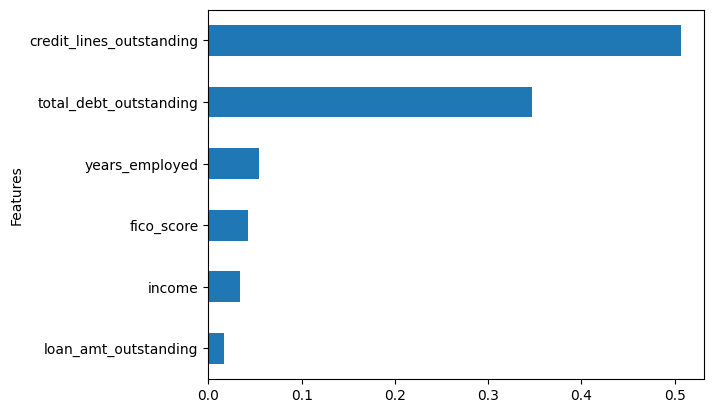

In [76]:
#(2.1.4) Data Relevance
# IDEA: computing feature importance scores using various methods to give us an idea what features to look at more closely during Feature Selection 

# perform feature importance analysis by deploying a RandomForestClassifier model

from sklearn.ensemble import RandomForestClassifier

# train the Random Forest Classifier model
# best practices ranges:
# SIZE OF DATASETS #####################
# Small: Fewer than 10,000 rows and <50 features.
# Medium: Between 10,000 and 1 million rows.
# Large: More than 1 million rows or hundreds/thousands of features.
# max_depth #############################
# For small or simple datasets, smaller depths (e.g., 3–5) are usually sufficient.
# For large or complex datasets, deeper trees (e.g., 10–20) may be necessary
# n_estimators ##########################
# For small to medium datasets, values between 100 and 500
# For larger datasets or when computational resources are not a concern, values between 500 and 1000

# define the input and target datasets
X_input = normalized_df.loc[:,[x for x in normalized_df.columns if x not in ['default']]]
y_target = normalized_df.loc[:, 'default']
# define the RFC model
rf = RandomForestClassifier(random_state=0, max_features='log2', max_depth=10, n_estimators=100)
# fit the RFC model
rf.fit(X_input, y_target)
# Extract feature importances
importances = rf.feature_importances_
# Visualize feture importances
import matplotlib.pyplot as plt

feat_importance_df = pd.DataFrame(data=[
                                        [x for x in normalized_df.columns if x not in ['default']],
                                        importances],
                                 )

feat_importance_df = feat_importance_df.T
feat_importance_df.columns = ['Features', 'Feature Importances']
feat_importance_df = feat_importance_df.set_index('Features')
feat_importance_df.sort_values('Feature Importances').plot(kind='barh', legend=False)

# NOTE: credit lines and total debt outstanding has the highest RFC Feature Importance scores
# take note of causality: if you have more credit lines open, the more probable that you will incur more debt

# feauture_importance is based on the RandomForest model's impurity-importance (e.g. Gini Impurity) during tree construction


Predictor Variable pair plots and correlation heat map
- in the pair plots, there is positive relationship between credit lines and total debt

<Figure size 1200x1000 with 0 Axes>

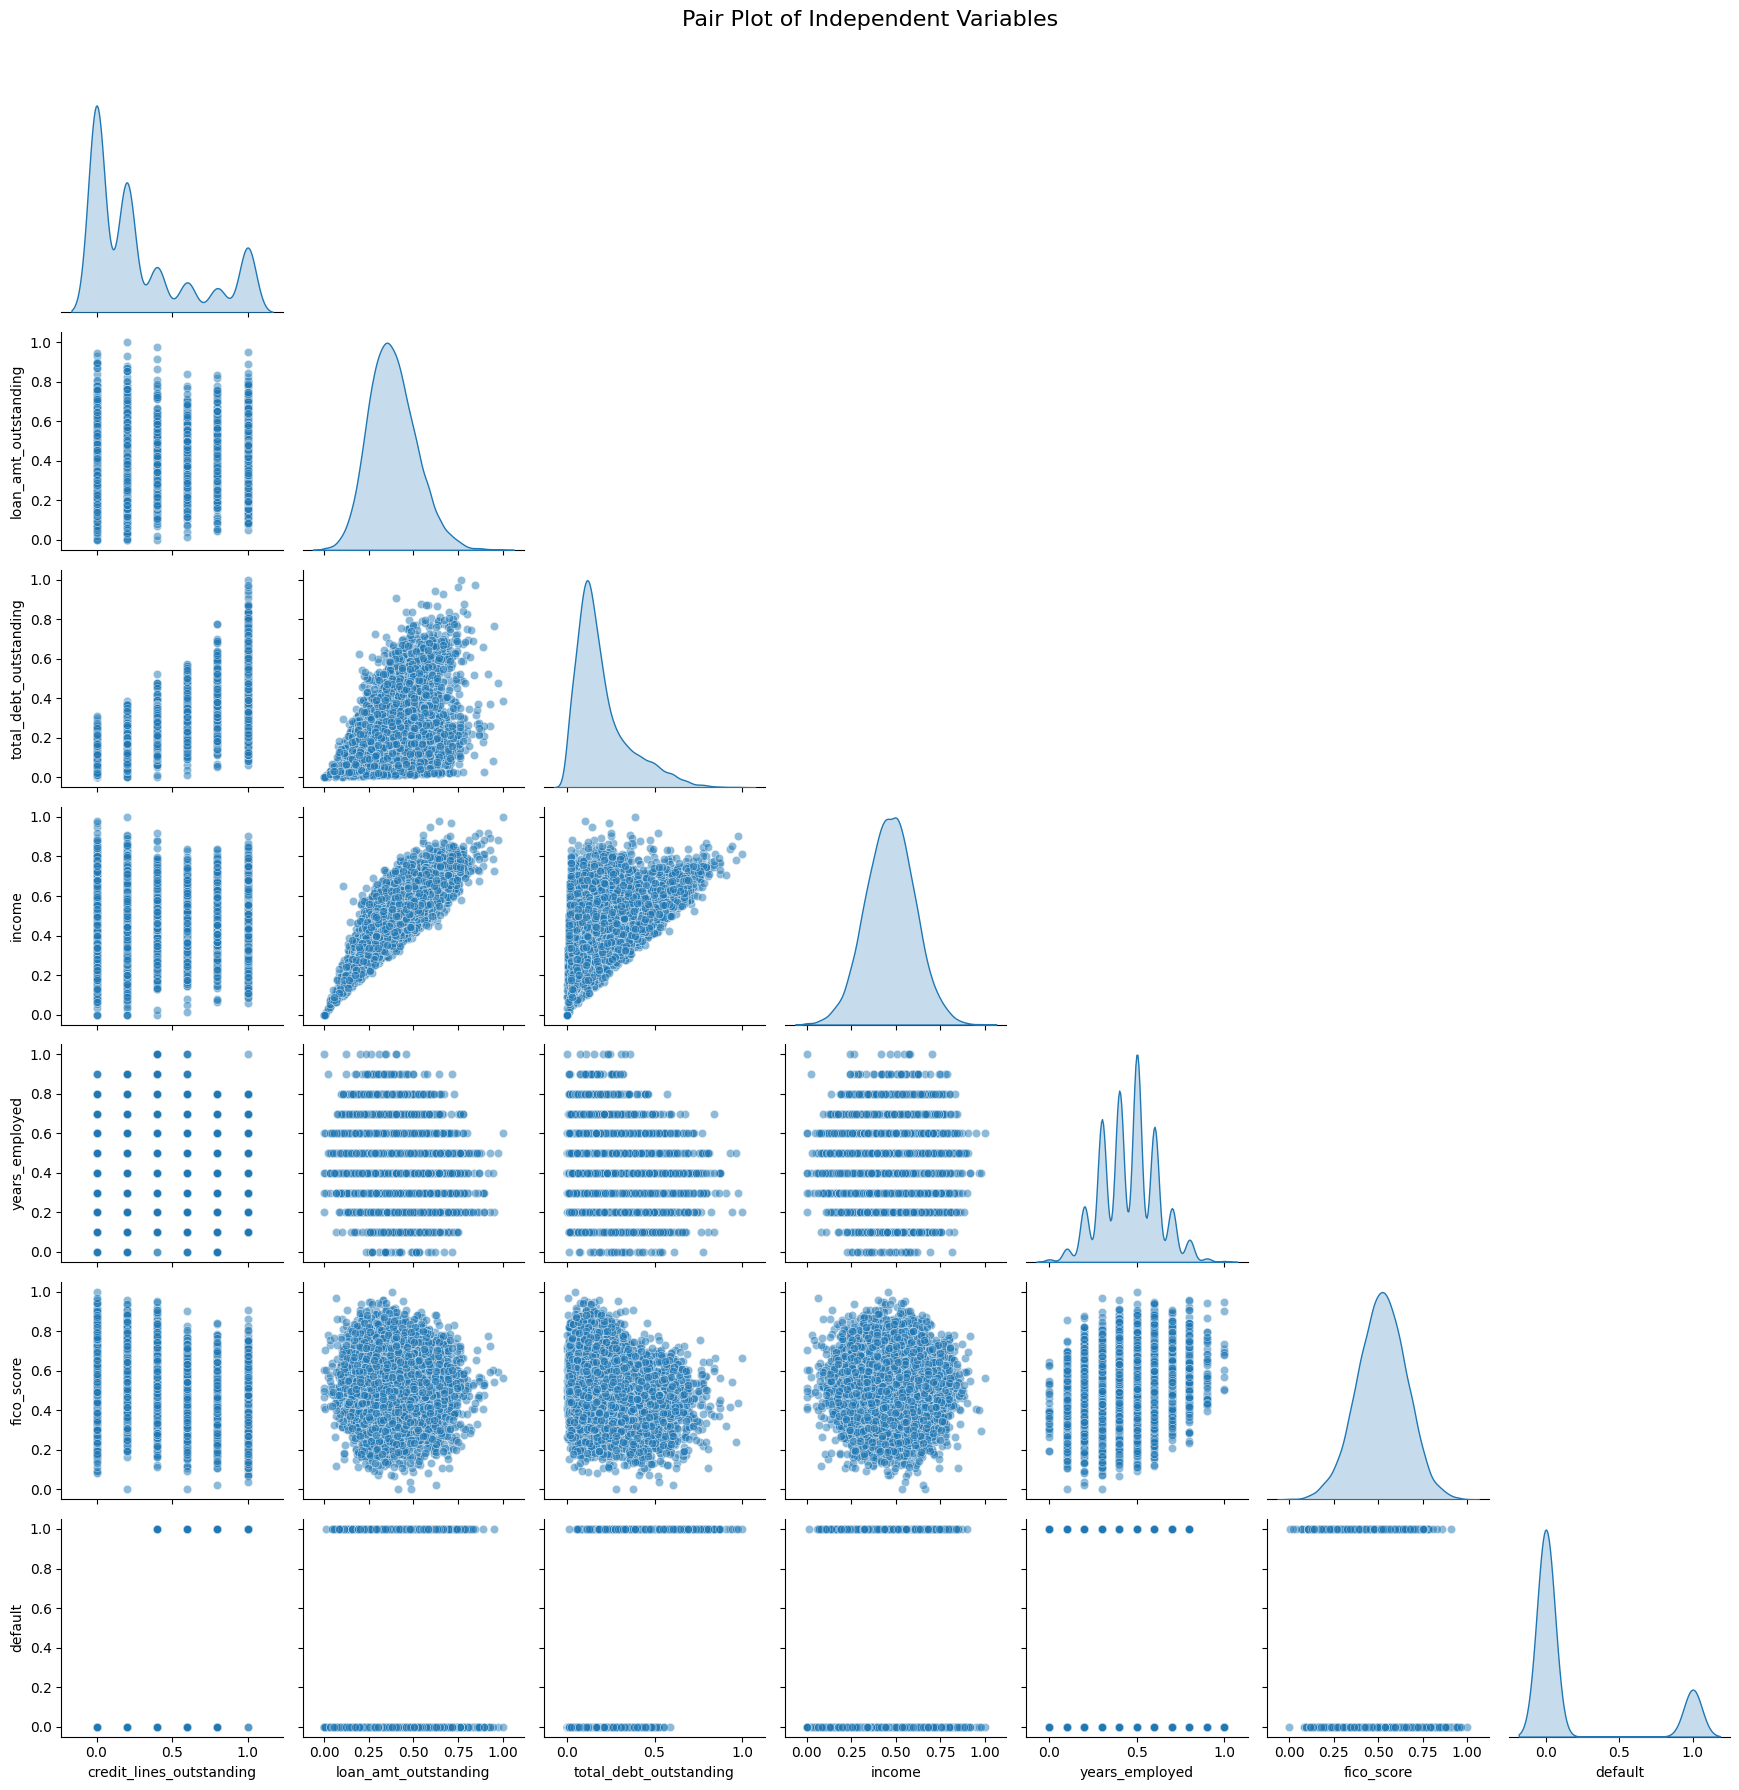

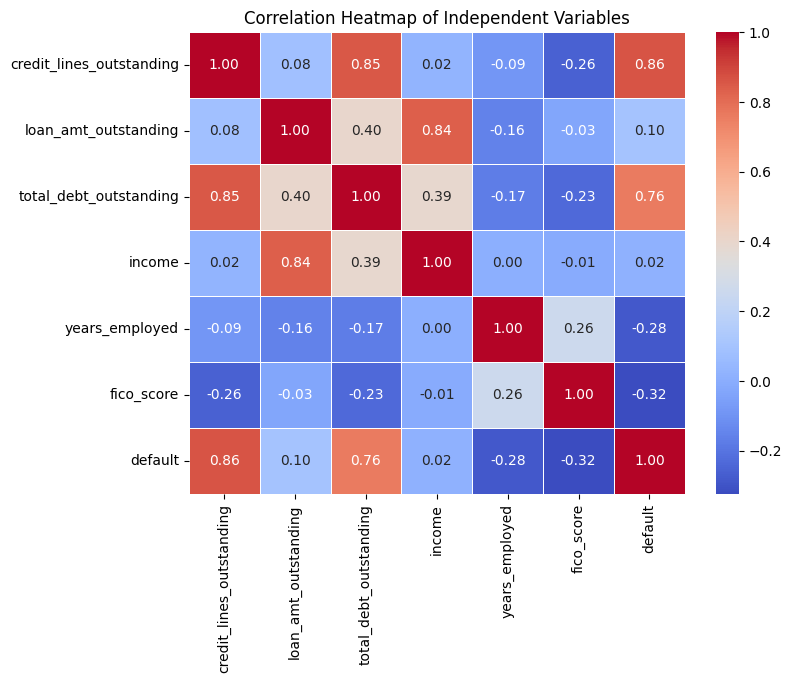

In [67]:
# (2.2.1) and (2.2.2) Feature Selection (and Feature Engineering if applicable)
# IDEA: we look out for relationships among independent variables and independent to depenedent variables

# Determine LINEAR Relationship among the independent variables in the dataset

# NOTE: modify viz_df in the above cells accordingly
viz_df = normalized_df.loc[:,[x for x in normalized_df.columns if x not in ['customer_id']]] # df.loc[:, selected_features]#  # choose the features to plot

plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(viz_df, diag_kind='kde', plot_kws={'alpha': 0.5}, corner=True)
pair_plot.fig.suptitle('Pair Plot of Independent Variables', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Correlation Heatmap to Quantify Multicollinearity
correlation_matrix = viz_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Independent Variables")
plt.show()


# REMARK: ask the professor on how to proceed with feature selection/engineering given the plots below


Mutual Information Scores for probabilisitc independence/dependence between predictor variables and target variable

Pairwise Mutual Information Scores:
                         credit_lines_outstanding loan_amt_outstanding  \
credit_lines_outstanding                        0             1.512236   
loan_amt_outstanding                     1.512236                    0   
total_debt_outstanding                   1.512236              9.21034   
income                                   1.511629             9.209265   
years_employed                           0.137445             1.862592   
fico_score                               0.140781             5.500121   
default                                  0.420882             0.479039   

                         total_debt_outstanding    income years_employed  \
credit_lines_outstanding               1.512236  1.511629       0.137445   
loan_amt_outstanding                    9.21034  9.209265       1.862592   
total_debt_outstanding                        0  9.209265       1.862592   
income                                 9.209265         0       1.8

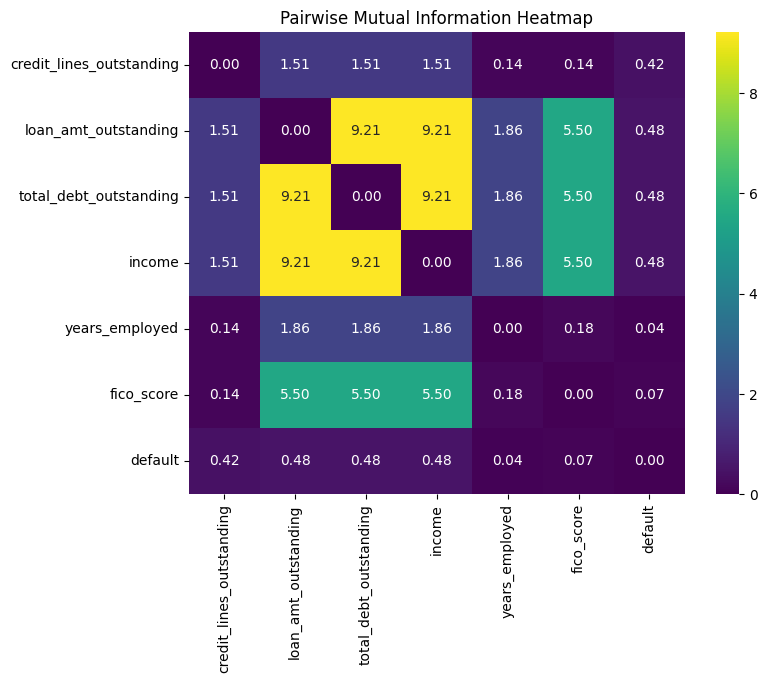

In [68]:
# Deploy Multivariate Mutual Information Scoring among each possible variable pair to determine independence/dependence in a probabilistic sense


import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

def pairwise_mutual_information(X):
    """
    Calculate pairwise mutual information scores for all feature pairs.
    
    Parameters:
    - X: Feature matrix (DataFrame or ndarray)
    
    Returns:
    - A DataFrame containing mutual information scores for each feature pair.
    """
    # Ensure X is a DataFrame for easier indexing
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
    
    # Initialize an empty DataFrame to store MI scores
    mi_matrix = pd.DataFrame(index=X.columns, columns=X.columns)
    
    # Calculate mutual information for each pair of features
    for i in range(len(X.columns)):
        for j in range(i, len(X.columns)):  # Only compute upper triangular (symmetric matrix)
            if i == j:
                mi_matrix.iloc[i, j] = 0  # MI with itself is zero
            else:
                mi_score = mutual_info_score(X.iloc[:, i], X.iloc[:, j])
                mi_matrix.iloc[i, j] = mi_score
                mi_matrix.iloc[j, i] = mi_score  # Symmetric value
    
    return mi_matrix

# Example usage with a synthetic dataset
from sklearn.datasets import make_classification

# Compute pairwise mutual information scores
# NOTE: modify viz_df in the above cells accordingly
pairwise_mi_scores = pairwise_mutual_information(viz_df)

# Display the results
print("Pairwise Mutual Information Scores:")
print(pairwise_mi_scores)

# Optional: Visualize the pairwise MI matrix as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(pairwise_mi_scores.astype(float), annot=True, cmap="viridis", fmt=".2f")
plt.title("Pairwise Mutual Information Heatmap")
plt.show()


# REMARKS:
# low score ~0 = variables are independent from each other - desired among independent variables
# high score = variables are dependent from each other - desired between independent and dependent variables

Feature Selection

In [97]:
# based from the above analysis, will use the following features
features = ['credit_lines_outstanding','fico_score', 'years_employed']
# inputs to chi-squared test
categorical_feat = ['fico_score'] # list out categorical variables 
continuous_feat = [x for x in features if x not in categorical_feat]


Verifications for meeting the Logistic Regression assumptions

Box-Tidwell test for linearity between predictor variables and target var and Chi-Squared test for probabilistic indepndence among predictor variables

In [99]:
# (2.3) Model Selection

'''
# MODEL 1: Logistic Regression
# as per industry standards, Logistic Regression is widely used for predicting Probability of Default
# theory: https://www.youtube.com/watch?v=zM4VZR0px8E


Assumptions of Logistic Regression

Binary or Ordinal Dependent Variable:
For binary logistic regression, the dependent variable must have two categories (e.g., yes/no, 0/1). For ordinal logistic regression, the dependent variable should have ordered categories135.

Independence of Observations:
The observations in the dataset must be independent of each other. This means there should be no repeated measurements or matched data unless accounted for in the model235.
 - use chi-squared test

No Perfect Multicollinearity:
The independent variables should not be perfectly correlated with each other. High multicollinearity can distort coefficient estimates and reduce interpretability357.


Linearity of Independent Variables and Log-Odds:
Logistic regression assumes that continuous independent variables have a linear relationship with the log-odds (logit) of the dependent variable. This can be checked using methods like the Box-Tidwell test or scatterplots with log-odds transformations235.
- Box-Tidwell test

Adequate Sample Size:
Logistic regression requires a sufficiently large sample size to ensure reliable estimates. A general rule is to have at least 10 cases with the least frequent outcome for each independent variable in the model35.

Absence of Strongly Influential Outliers:
Outliers can significantly impact the results of logistic regression. It is important to identify and address such data points during analysis7.

'''

# BOX-TIDWELL TEST function definition

import numpy as np
import pandas as pd
import statsmodels.api as sm
import warnings

# Suppress warnings to keep output clean
warnings.filterwarnings('ignore')

def box_tidwell_test(X, y, alpha=0.05):
    """
    Perform the Box-Tidwell test to check the linearity assumption of continuous predictors 
    in logistic regression.
    
    Parameters:
    -----------
    X : pandas DataFrame
        Continuous predictors (each column is a predictor).
    y : pandas Series or numpy array
        Binary outcome variable (0 or 1).
    alpha : float, optional (default=0.05)
        Significance level for hypothesis testing.
    
    Returns:
    --------
    results : dict
        Dictionary containing p-values and linearity assumption results for each predictor.
    """
    
    # Ensure all predictors are positive by adding a small constant if necessary
    X_adjusted = X + 1  # Add 1 to avoid log(0)
    
    # Create interaction terms: X * log(X)
    interaction_terms = X_adjusted * np.log(X_adjusted)
    
    # Rename interaction term columns
    interaction_terms.columns = [f"{col}_interaction" for col in X.columns]
    
    # Combine original predictors and interaction terms into one DataFrame
    predictors = pd.concat([X_adjusted, interaction_terms], axis=1)
    
    # Add a constant for the intercept in logistic regression
    predictors = sm.add_constant(predictors)
    
    # Fit logistic regression model with both original predictors and interaction terms
    model = sm.Logit(y, predictors).fit(disp=False)
    
    # Extract p-values for the interaction terms (after original predictors)
    num_predictors = X.shape[1]
    p_values = model.pvalues[num_predictors + 1:]  # Skip intercept and original predictors
    
    # Determine linearity assumption based on p-values
    results = {}
    for i, predictor in enumerate(X.columns):
        p_value = p_values[i]
        results[predictor] = {
            "p_value": p_value,
            "linearity_holds": p_value > alpha,  # True if linearity assumption holds
            "coefficient": model.params[num_predictors + 1 + i]  # Interaction term coefficient
        }
    
    return results




# CHI-SQUARED TEST with discretization step for continuous independent variables

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.preprocessing import KBinsDiscretizer

def chi_squared_mixed_dataset(df, categorical_cols=None, continuous_cols=None, n_bins=5, alpha=0.05):
    """
    Perform chi-squared test on all possible variable pairs in a mixed dataset and indicate independence.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataset with mixed variable types.
    categorical_cols : list, optional
        List of categorical column names.
    continuous_cols : list, optional
        List of continuous column names.
    n_bins : int, default 5
        Number of bins for discretizing continuous variables.
    alpha : float, default 0.05
        Significance level for determining independence.
    
    Returns:
    --------
    results : dict
        Dictionary containing chi-squared statistics, p-values, and independence indicators as DataFrames.
    """
    # Infer column types if not provided
    if categorical_cols is None and continuous_cols is None:
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
        continuous_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    # Discretize continuous variables
    if continuous_cols:
        discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        df.loc[:,continuous_cols] = discretizer.fit_transform(df[continuous_cols])
    
    # Combine all columns for pairwise analysis
    all_cols = categorical_cols + continuous_cols
    
    # Initialize matrices for results
    n_cols = len(all_cols)
    chi2_matrix = np.zeros((n_cols, n_cols))
    pvalue_matrix = np.zeros((n_cols, n_cols))
    independence_matrix = np.full((n_cols, n_cols), True)  # Default to True (independent)
    
    # Compute chi-squared tests for all pairs
    for i in range(n_cols):
        for j in range(i, n_cols):
            contingency_table = pd.crosstab(df[all_cols[i]], df[all_cols[j]])
            chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
            chi2_matrix[i, j] = chi2_stat
            chi2_matrix[j, i] = chi2_stat
            pvalue_matrix[i, j] = p_value
            pvalue_matrix[j, i] = p_value
            
            # Determine independence based on the p-value and significance level (alpha)
            is_independent = p_value > alpha
            independence_matrix[i, j] = is_independent
            independence_matrix[j, i] = is_independent
    
    # Convert matrices to DataFrames
    chi2_df = pd.DataFrame(chi2_matrix, index=all_cols, columns=all_cols)
    pvalue_df = pd.DataFrame(pvalue_matrix, index=all_cols, columns=all_cols)
    independence_df = pd.DataFrame(independence_matrix, index=all_cols, columns=all_cols)
    
    return {
        'chi2_statistics': chi2_df,
        'p_values': pvalue_df,
        'independence': independence_df
    }

######################## APPLYING THE TESTS ###############################

# Before deploying a LogisticRegression model, we need to check if our dataset satisfies the assumptions of this model

input_df = df.copy(deep=True)
# CHI-SQUARED TEST: test for [probabilistic] independence among independent variables
print('========= CHI-SQUARED TEST =========\n')
results = chi_squared_mixed_dataset(
    df[features],
    categorical_cols= categorical_feat, #["credit_lines_outstanding", "years_employed", "fico_score"],
    continuous_cols= continuous_feat, #["loan_amt_outstanding", "total_debt_outstanding", 'income'],
    alpha=0.05  # Significance level for independence test
)

print("Chi-squared Statistics:")
print(results['chi2_statistics'])
print("\nP-values:")
print(results['p_values'])
print("\nIndependence (True indicates independent):")
print(results['independence'])



# BOX-TIDWELL TEST: test for linear relationship of independent variables with the logit of the dependent variable
print('\n========= BOX-TIDWELL TEST =========\n')
# Input Data
X = normalized_df[features] # df.loc[:, [x for x in df.columns if x!='default']]
y = normalized_df['default']

# Perform Box-Tidwell Test on synthetic data
results = box_tidwell_test(X, y)

# Display results
print("Box-Tidwell Test Results:")
print("-" * 50)
for predictor, result in results.items():
    print(f"{predictor}:")
    print(f"  P-value: {result['p_value']:.4f}")
    print(f"  Coefficient: {result['coefficient']:.4f}")
    print(f"  Linearity Assumption: {'Linearity Holds' if result['linearity_holds'] else 'Violated'}")




# CHI-SQUARED TEST with discretization step for continuous independent variables
# Null Hypothesis: The two variables are independent
# Alternative Hypothesis: The two variables are not independent
# NOTE: you want independent variables to FAIL TO REJECT the H0 (i.e. independent variables are probabilistically independent) to satisfy assumption for Logistic Regression

# BOX-TIDWELL TEST function definition
# Null Hypothesis: The coefficient for the interaction term is not significant, which implies that the relationship between the predictor (independent) variable and the logit is linear
# Alternative Hypothesis: The coefficient for the interaction term is significant, which implies that the relationship between the predictor variable and the logit is non-linear
# NOTE: you want the the test to result to FAIL TO REJECT the H0 meaning that the log transformations of the independent variables are linear and meets the assumption of the Logistic Regression



========= CHI-SQUARED TEST =========

Chi-squared Statistics:
                            fico_score  credit_lines_outstanding  \
fico_score                3.730000e+06               1666.086157   
credit_lines_outstanding  1.666086e+03              20000.000000   
years_employed            2.192087e+03               1762.341911   

                          years_employed  
fico_score                   2192.086767  
credit_lines_outstanding     1762.341911  
years_employed              40000.000000  

P-values:
                            fico_score  credit_lines_outstanding  \
fico_score                0.000000e+00              3.886605e-72   
credit_lines_outstanding  3.886605e-72              0.000000e+00   
years_employed            1.305328e-29              0.000000e+00   

                          years_employed  
fico_score                  1.305328e-29  
credit_lines_outstanding    0.000000e+00  
years_employed              0.000000e+00  

Independence (True indicates indepen

Metrics for evaluating predictive model

In [ ]:
# (2.3) Model Selection - pre-amble

# Function for evaluating predictive models

def evaluate_model(y_true, y_pred, y_scores):

    import numpy as np
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        log_loss,
        roc_auc_score,
        average_precision_score,
        confusion_matrix,
        roc_curve,
        auc
    )
    import matplotlib.pyplot as plt



    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cross_entropy_loss = log_loss(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    # Print metrics
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"cross_entropy_loss: {cross_entropy_loss:.2f}")
    print(f"ROC-AUC: {roc_auc:.2f}")
    print(f"PR-AUC: {pr_auc:.2f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Optional: Plot Precision-Recall Curve
    from sklearn.metrics import precision_recall_curve

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_scores)
    plt.figure()
    plt.plot(recall_vals, precision_vals,
            label=f'PR curve (AUC = {pr_auc:.2f})', color='blue')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()
    


Build the Logistic Regression model

Coefficients: [[13.51337377 -3.37823734 -7.31082873]]
Intercept: [-4.35055167]
Accuracy: 0.99
Precision: 0.99
Recall: 0.97
F1 Score: 0.98
cross_entropy_loss: 0.23
ROC-AUC: 1.00
PR-AUC: 1.00

Confusion Matrix:
[[2035    4]
 [  12  449]]


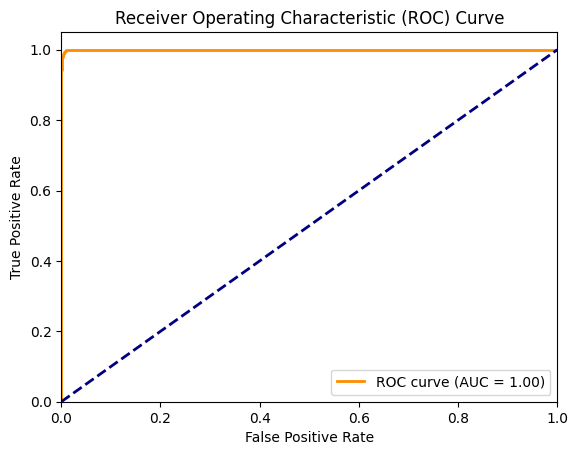

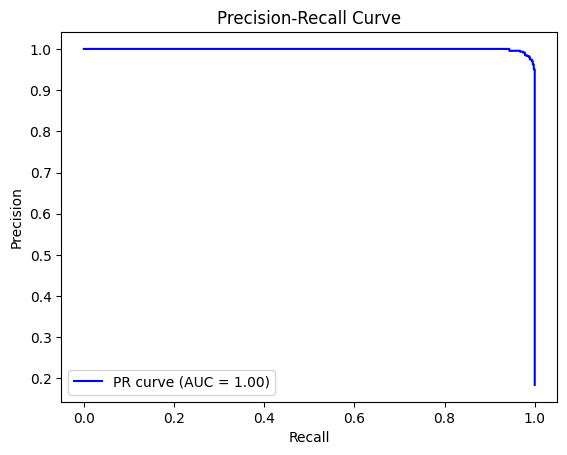

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load your dataset (replace with your own data)
# X: Features, y: Target variable (binary)

# features = ['total_debt_outstanding', 'fico_score']

'''
Normalizing Dataset if required

# Normalizing independent variables since it is best practice for logistic regression
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the dataset
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(data=df_scaled, columns=df.columns)
'''

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(normalized_df[features], normalized_df['default'], random_state=7)

# Initialize the logistic regression model
model = LogisticRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# show the regression coefficients and intercept:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# process inputs and outputs for evaluation
y_true = y_test
y_scores = model.predict_proba(X_test)[:,1]

evaluate_model(y_true, y_pred, y_scores)

# REMARK: cross_entropy_loss is interpreted as the distance between two probability distributions (i.e. true and predicted)
#         lower values are desirable

 

In [103]:
# (2.5) Hyperparmeter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {'C': [0.0001, 0.001, 0.01, 0.1, 1, 100], 
              'penalty': ['elasticnet'], 
              'l1_ratio': np.arange(start=0, stop=1, step=0.1),
              'solver': ['saga'] # only set to saga in order to use elasticnet
              }
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(normalized_df[features], normalized_df['default'])
print("Best Parameters:", grid_search.best_params_)



Best Parameters: {'C': 100, 'l1_ratio': 0.0, 'penalty': 'elasticnet', 'solver': 'saga'}


Coefficients: [[ 51.5939015  -12.90598132 -34.3521064 ]]
Intercept: [-12.87622167]
Accuracy: 1.00
Precision: 0.99
Recall: 1.00
F1 Score: 0.99
cross_entropy_loss: 0.09
ROC-AUC: 1.00
PR-AUC: 1.00

Confusion Matrix:
[[2035    4]
 [   2  459]]


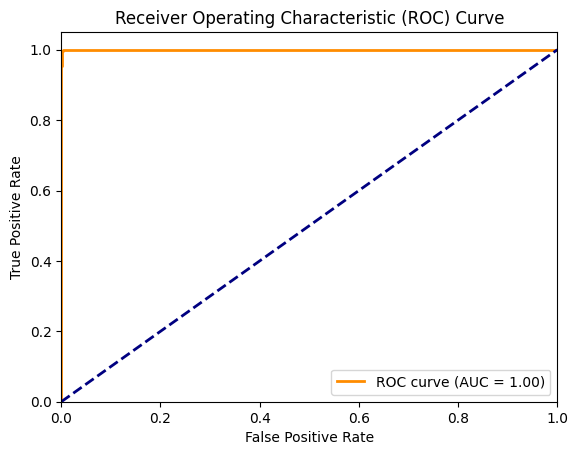

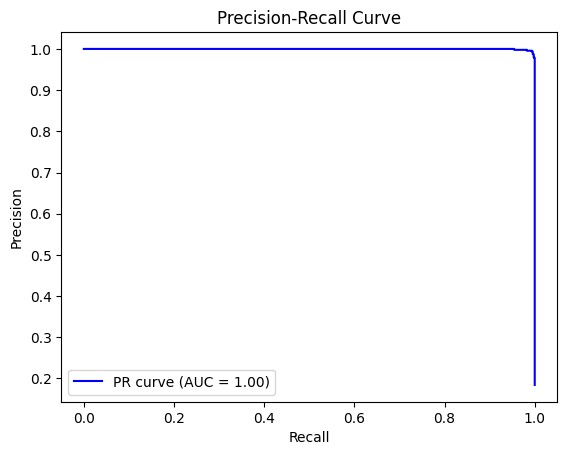

In [104]:
# apply the best parameters and re-evaluate

# Initialize the logistic regression model
model = LogisticRegression(C=grid_search.best_params_['C'], 
                           l1_ratio=grid_search.best_params_['l1_ratio'], 
                           penalty=grid_search.best_params_['penalty'], 
                           solver=grid_search.best_params_['solver'])

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# show the regression coefficients and intercept:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# process inputs and outputs for evaluation
y_true = y_test
y_scores = model.predict_proba(X_test)[:,1]

evaluate_model(y_true, y_pred, y_scores)